<a href="https://colab.research.google.com/github/ayualfia/5026231033/blob/main/Notebook/4_POS_%26_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# Install Library
# ==============================
!pip install stanza tqdm matplotlib seaborn transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 15.8 MB/s eta 0:00:00


In [ ]:
# ==============================
# Import Library
# ==============================
import pandas as pd
import stanza
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from IPython.display import display, HTML
from collections import Counter, defaultdict
import ast

In [ ]:
# ==============================
# Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

# ==============================
# Load Dataset
# ==============================
file_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_preprocessing_pertamina.csv'  # ganti sesuai folder
df = pd.read_csv(file_path)

df['final_text_stemmed'] = df['final_text_stemmed'].fillna("").astype(str)
print(df.head())

                                                Link  \
0  https://money.kompas.com/image/2017/10/03/1815...   
1  https://money.kompas.com/read/2016/06/06/14280...   
2  https://money.kompas.com/read/2017/02/03/12195...   
3  https://money.kompas.com/read/2016/05/27/20434...   
4  https://money.kompas.com/read/2017/03/24/11200...   

                                               Judul  \
0  Foto : CSR Pertamina Lubricants Kini Fokus ke ...   
1  Gandeng Dua Bank, Pertamina Lubricants Yakin P...   
2  Dua Pucuk Pimpinan Pertamina Dicopot, Yenni An...   
3  Ini yang Dilakukan PTKAM untuk Efisiensi 'Oil ...   
4  Ini Tugas Pertama Adiatma Sardjito Sebagai Jub...   

                                          Isi Berita   Status  \
0  Diskusi mengenai CSR di industri pelumas berta...  success   
1  JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...  success   
2  JAKARTA, KOMPAS.com — Pasca-pencopotan dua puc...  success   
3  JAKARTA, KOMPAS.com - PT Pertamina (persero) t...  success   
4

In [ ]:
# ==============================
# Download & Load Stanza (POS)
# ==============================
stanza.download('id')
nlp = stanza.Pipeline(lang='id', processors='tokenize,pos')

INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


In [ ]:
# ==============================
# POS Tagging
# ==============================
def pos_tagging(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    doc = nlp(text)
    tokens_pos = []
    for sent in doc.sentences:
        for word in sent.words:
            tokens_pos.append((word.text, word.pos))
    return tokens_pos

tqdm.pandas()
df['POS'] = df['final_text_stemmed'].progress_apply(pos_tagging)

100%|██████████| 1883/1883 [12:38<00:00,  2.48it/s]


In [ ]:
# ==============================
# Expand POS ke Tabel per Token
# ==============================
df = df.reset_index(drop=True)

# Expand POS ke tabel per token
rows = []
for idx, row in df.iterrows():
    for word, pos in row['POS']:
        rows.append({
            'content_id': idx,  # idx sekarang 0,1,2,... sesuai baris
            'word': word,
            'pos': pos
        })
df_detail = pd.DataFrame(rows)
df_detail

,content_id,word,pos
0,0,diskusi,NOUN
1,0,kena,NOUN
2,0,csr,NOUN
3,0,industri,NOUN
4,0,lumas,NOUN
...,...,...,...
478990,1881,situs,NOUN
478991,1881,web,NOUN
478992,1881,izin,NOUN
478993,1881,tulis,NOUN


In [ ]:
# ==============================
# Visualisasi POS Warna-warni (sample baris ke-8)
# ==============================
from IPython.display import HTML, display

pos_colors = {
    'NOUN':  '#8ED1E8',   # pastel biru
    'VERB':  '#F77878',   # pastel coral
    'ADJ':   '#B7E48A',   # pastel hijau muda
    'ADV':   '#C8B6F2',   # pastel ungu
    'PROPN': '#84B9E8',   # pastel biru langit
    'PRON':  '#F6D1DC',   # pastel pink muda
    'ADP':   '#F3E55B',   # pastel kuning
    'DET':   '#F3C38C',   # pastel peach
    'CONJ':  '#6FA8E8',   # pastel biru
    'SCONJ': '#E7B7D8',   # pastel pink-lilac
    'AUX':   '#F6AE61',   # pastel orange
    'PUNCT': '#E6E3DF',   # abu lembut
    'NUM':   '#F7B6D2',   # pink pastel
    'PART':  '#98E2CF',   # mint pastel
    'INTJ':  '#FFD966',   # kuning hangat
    'SYM':   '#D9D9D9',   # abu muda
    'X':     '#D6CDEA'    # lavender abu
}

sample_text = df['final_text_clean'].iloc[6]
doc = nlp(sample_text)

html = "<div style='line-height: 2.5; font-family: Arial, sans-serif;'>"

for sent in doc.sentences:
    for token in sent.words:
        color = pos_colors.get(token.pos, "#E6E3DF")
        html += f"""
        <span style="
            background-color:{color};
            color:#333333;
            padding:6px 10px;
            margin:3px;
            border-radius:16px;
            display:inline-block;
            font-size:14px;
        ">
            {token.text} <strong>{token.pos}</strong>
        </span>
        """

html += "</div>"
display(HTML(html))

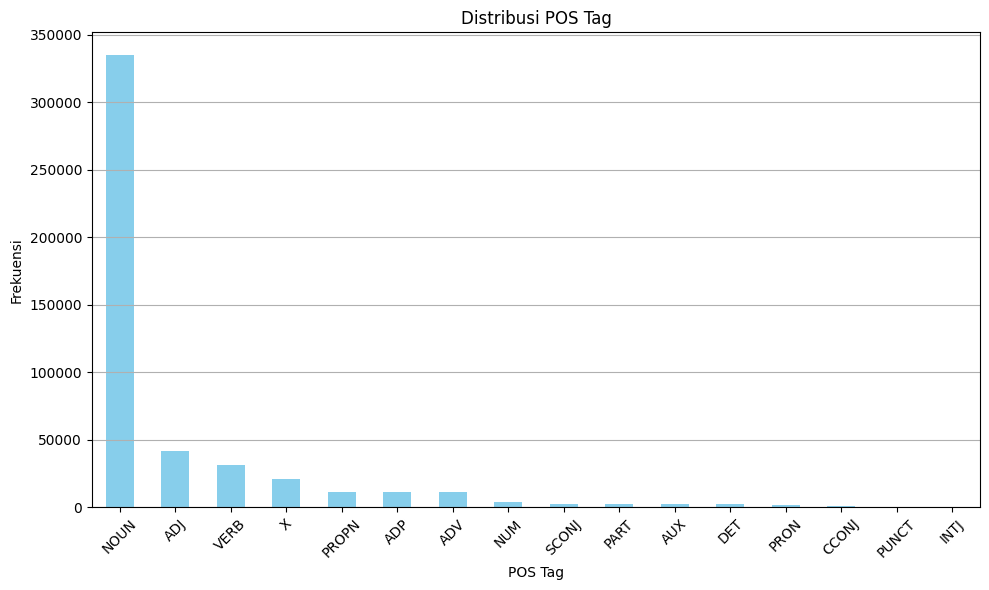

In [ ]:
# ==============================
# Bar Chart Distribusi POS
# ==============================
pos_counts = df_detail['pos'].value_counts()
plt.figure(figsize=(10,6))
pos_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Hitung frekuensi tiap POS
pos_counts = df_detail['pos'].value_counts().reset_index()
pos_counts.columns = ['POS Tag', 'Frekuensi']

# Tampilkan tabel
pos_counts

,POS Tag,Frekuensi
0,NOUN,335163
1,ADJ,41943
2,VERB,31148
3,X,20657
4,PROPN,11498
5,ADP,11473
6,ADV,11430
7,NUM,4004
8,SCONJ,2387
9,PART,2300
